In [2]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [4]:
# Cell 2 — Load and inspect dataset
df = pd.read_csv('../data/dataset.csv')

print("Shape:", df.shape)
print("\nSamples per letter:")
print(df['label'].value_counts().sort_index())

Shape: (9600, 64)

Samples per letter:
label
A    400
B    400
C    400
D    400
E    400
F    400
G    400
H    400
I    400
K    400
L    400
M    400
N    400
O    400
P    400
Q    400
R    400
S    400
T    400
U    400
V    400
W    400
X    400
Y    400
Name: count, dtype: int64


In [5]:
# Cell 3 — Separate features and labels
X = df.drop(columns=['label']).values  # shape: (9600, 63)
y = df['label'].values                 # shape: (9600,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample y values:", y[:5])

X shape: (9600, 63)
y shape: (9600,)
Sample y values: <StringArray>
['A', 'A', 'A', 'A', 'A']
Length: 5, dtype: str


In [6]:
# Cell 4 — Wrist normalization
# Subtract wrist (landmark 0) x and y from all landmarks
# Z is kept as-is — it already represents depth relative to the wrist

X_normalized = X.copy().reshape(-1, 21, 3)  # reshape to (9600, 21, 3) for easier indexing

wrist_x = X_normalized[:, 0, 0]  # shape (9600,)
wrist_y = X_normalized[:, 0, 1]

X_normalized[:, :, 0] -= wrist_x[:, np.newaxis]  # subtract from all 21 x values
X_normalized[:, :, 1] -= wrist_y[:, np.newaxis]  # subtract from all 21 y values

X_normalized = X_normalized.reshape(-1, 63)  # flatten back to (9600, 63)

print("Wrist x after normalization (should all be 0.0):", X_normalized[:5, 0])
print("Wrist y after normalization (should all be 0.0):", X_normalized[:5, 1])

Wrist x after normalization (should all be 0.0): [0. 0. 0. 0. 0.]
Wrist y after normalization (should all be 0.0): [0. 0. 0. 0. 0.]


In [7]:
# Cell 5 — Scale normalization
# Divide each sample by its own max absolute value
# This makes hand size and distance irrelevant — only shape matters

max_vals = np.max(np.abs(X_normalized), axis=1, keepdims=True)  # shape: (9600, 1)
X_normalized = X_normalized / max_vals

print("Min value in dataset:", X_normalized.min())
print("Max value in dataset:", X_normalized.max())
print("Sample row (first 9 values):", X_normalized[0, :9].round(4))

Min value in dataset: -1.0
Max value in dataset: 1.0
Sample row (first 9 values): [ 0.      0.     -0.     -0.2607 -0.139  -0.069  -0.4693 -0.4191 -0.0929]


In [9]:
# Cell 6 — Label encoding and train/val split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Convert letter strings to integers (A=0, B=1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # e.g. 'A' -> 0, 'B' -> 1

# Convert integers to one-hot vectors for categorical_crossentropy
y_onehot = keras.utils.to_categorical(y_encoded, num_classes=24)

# 80/20 split, stratified so each letter is equally represented in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("Classes:", list(le.classes_))

X_train: (7680, 63)
X_val:   (1920, 63)
y_train: (7680, 24)
y_val:   (1920, 24)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [10]:
# Cell 7 — Build the model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(63,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(24, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               8192      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 24)                1560      
                                                                 
Total params: 18008 (70.34 KB)
Trainable params: 18008 (70.34 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# Cell 8 — Train the model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='../model/fsl_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

print("\nBest validation accuracy:", max(history.history['val_accuracy']))

Epoch 1/100
222/240 [==========================>...] - ETA: 0s - loss: 2.0598 - accuracy: 0.3744

d:\fsl-classifier\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


240/240 [==============================] - 5s 5ms/step - loss: 1.9905 - accuracy: 0.3914 - val_loss: 0.7982 - val_accuracy: 0.8521
Epoch 2/100
240/240 [==============================] - 1s 3ms/step - loss: 0.7785 - accuracy: 0.7286 - val_loss: 0.3282 - val_accuracy: 0.9167
Epoch 3/100
240/240 [==============================] - 1s 3ms/step - loss: 0.4385 - accuracy: 0.8525 - val_loss: 0.1515 - val_accuracy: 0.9969
Epoch 4/100
240/240 [==============================] - 1s 3ms/step - loss: 0.2757 - accuracy: 0.9211 - val_loss: 0.0808 - val_accuracy: 0.9969
Epoch 5/100
240/240 [==============================] - 1s 3ms/step - loss: 0.1829 - accuracy: 0.9479 - val_loss: 0.0429 - val_accuracy: 0.9990
Epoch 6/100
240/240 [==============================] - 1s 4ms/step - loss: 0.1313 - accuracy: 0.9685 - val_loss: 0.0317 - val_accuracy: 0.9990
Epoch 7/100
240/240 [==============================] - 1s 3ms/step - loss: 0.0937 - accuracy: 0.9771 - val_loss: 0.0185 - val_accuracy: 1.0000
Epoch 8/100

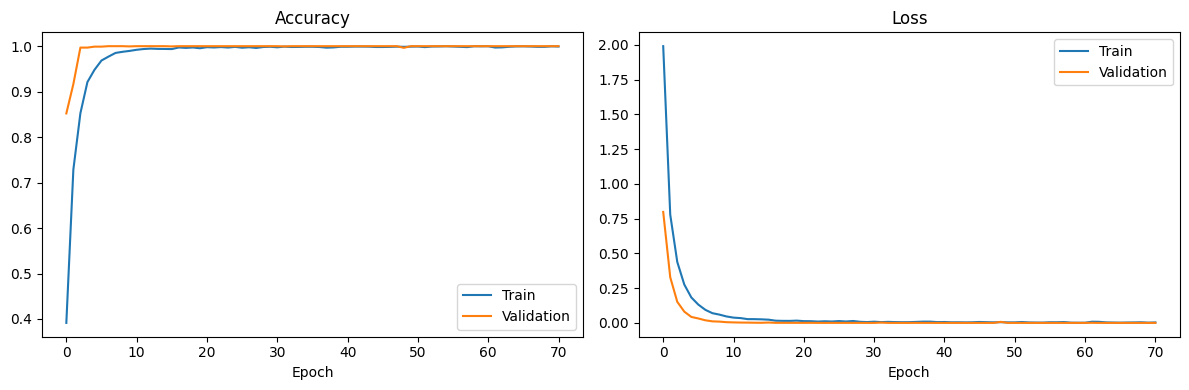

In [12]:
# Cell 9 — Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('../notebook/training_curves.png')
plt.show()

60/60 [==============================] - 0s 2ms/step


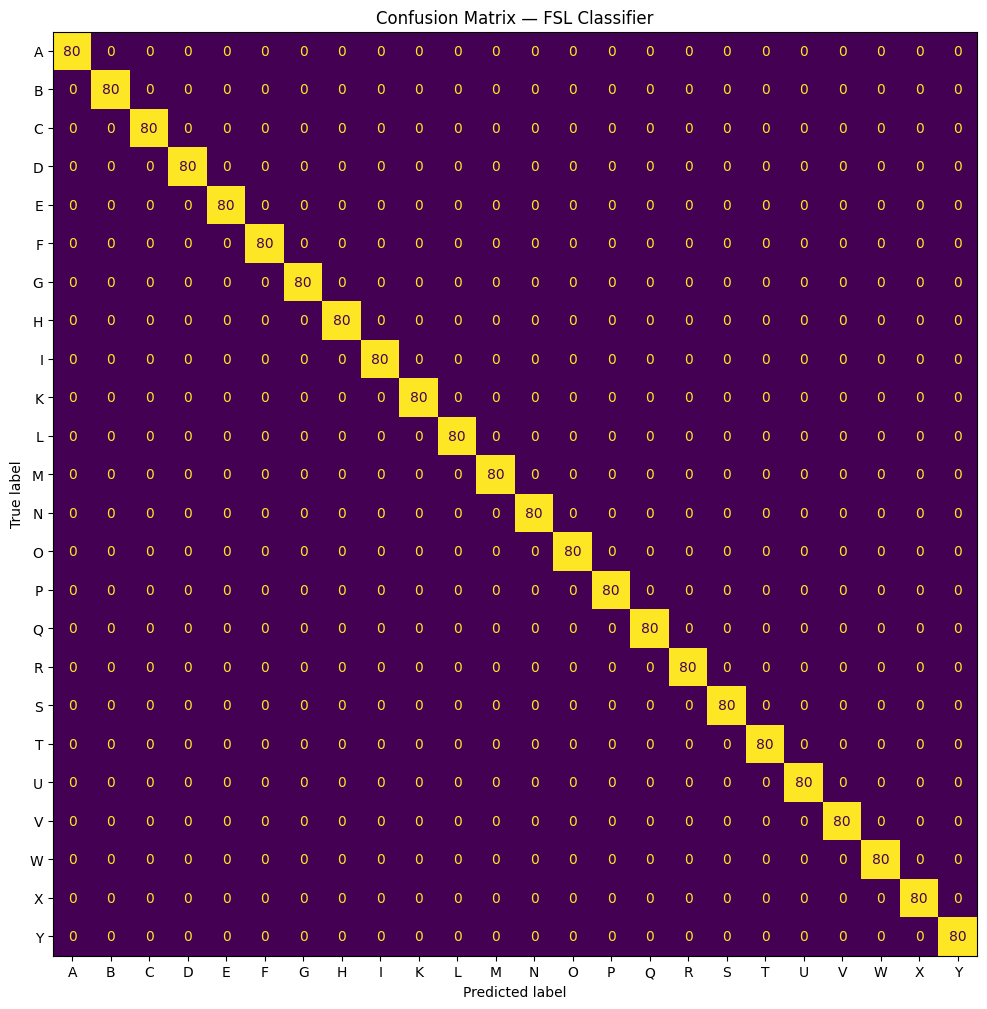

In [13]:
# Cell 10 — Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix — FSL Classifier')
plt.savefig('../notebook/confusion_matrix.png')
plt.show()